Cell 1 — Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             balanced_accuracy_score)
from sklearn.preprocessing import StandardScaler
import joblib
import os

Why these libraries?

numpy/pandas — handle our data arrays
sklearn — the Random Forest model and evaluation tools
matplotlib/seaborn — plots and visualizations
joblib — save the trained model so we don't have to retrain every time

Cell 2 — Load Bri's output

In [3]:
# ── Load preprocessed data ───────────────────────────────────────────────
# Bri's preprocessing pipeline outputs this file
# It contains X_train, X_test, y_train, y_test, feature_names
data = np.load("preprocessed/riga/train_data_flat.npz", allow_pickle=True)

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
feature_names = list(data["feature_names"])

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")
print(f"Features         : {X_train.shape[1]}")
print(f"Feature names    : {feature_names}")

Training samples : 759,785
Test samples     : 189,947
Features         : 38
Feature names    : [np.str_('anisotropy_0.1'), np.str_('anisotropy_0.3'), np.str_('anisotropy_0.5'), np.str_('density'), np.str_('eigenvalue_1_0.1'), np.str_('eigenvalue_1_0.3'), np.str_('eigenvalue_1_0.5'), np.str_('eigenvalue_1_1.0'), np.str_('eigenvalue_2_0.1'), np.str_('eigenvalue_2_0.3'), np.str_('eigenvalue_2_0.5'), np.str_('eigenvalue_2_1.0'), np.str_('eigenvalue_3_0.1'), np.str_('eigenvalue_3_0.3'), np.str_('eigenvalue_3_0.5'), np.str_('eigenvalue_3_1.0'), np.str_('height_above_min'), np.str_('height_division'), np.str_('height_range'), np.str_('height_std'), np.str_('intensity_normalized'), np.str_('linearity_0.1'), np.str_('linearity_0.3'), np.str_('linearity_0.5'), np.str_('normalized_z'), np.str_('omnivariance_0.1'), np.str_('omnivariance_0.3'), np.str_('omnivariance_0.5'), np.str_('planarity_0.1'), np.str_('planarity_0.3'), np.str_('planarity_0.5'), np.str_('roughness_0.1'), np.str_('roughness_0.3'

Why this approach?
Bri's preprocessing already did the hard work — loading the .laz file, computing features, splitting into train/test. We just load the result. This is good software engineering — each person handles their part.

Cell 3 — Understand the labels

Class distribution in training data:
    2 (sidewalk  ):    225,597 points (29.7%)
    3 (class_3   ):     94,484 points (12.4%)
    4 (class_4   ):     14,651 points (1.9%)
    5 (class_5   ):     45,348 points (6.0%)
    8 (class_8   ):     21,550 points (2.8%)
   11 (street    ):    300,541 points (39.6%)
   13 (class_13  ):        335 points (0.0%)
   15 (class_15  ):     57,279 points (7.5%)


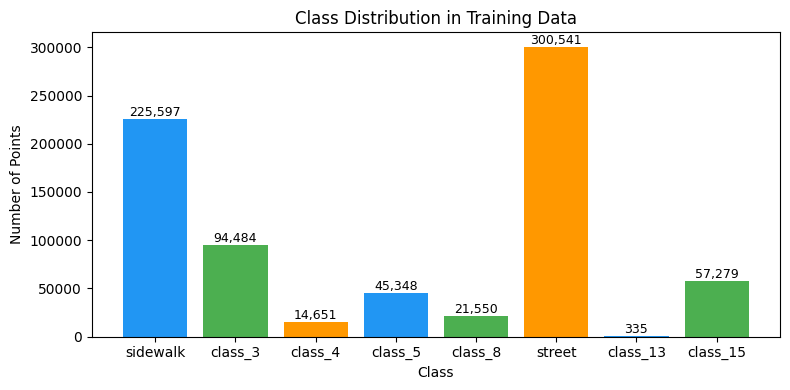

In [4]:
# ── Explore class distribution ───────────────────────────────────────────
# IFP classification codes:
# 2  = sidewalk (pedestrian surface)
# 11 = street/road (carriageway)
# everything else = other (buildings, trees, cars, furniture)

CLASS_NAMES = {2: "sidewalk", 11: "street", 0: "other"}

unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution in training data:")
for cls, count in zip(unique, counts):
    name = CLASS_NAMES.get(int(cls), f"class_{cls}")
    pct  = 100 * count / len(y_train)
    print(f"  {cls:3d} ({name:10s}): {count:>10,} points ({pct:.1f}%)")

# Plot it
plt.figure(figsize=(8, 4))
names  = [CLASS_NAMES.get(int(c), f"class_{c}") for c in unique]
colors = ["#2196F3", "#4CAF50", "#FF9800"]
plt.bar(names, counts, color=colors)
plt.title("Class Distribution in Training Data")
plt.ylabel("Number of Points")
plt.xlabel("Class")
for i, (name, count) in enumerate(zip(names, counts)):
    plt.text(i, count, f"{count:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

Why this matters?
This is where we confirm the class imbalance problem. James found that "other" dominates with 80%+ of points. If we don't handle this, the model just predicts "other" for everything and looks accurate but is useless for finding sidewalks and roads.

Cell 4 — Remap labels

In [15]:
# Remap labels to 3 clean classes:
# 0 = other (everything that isn't road or sidewalk)
# 1 = sidewalk 
# 2 = street 

def remap_labels(y):
    y_new = np.zeros_like(y)    # everything starts as 0 (other)
    y_new[y == 2]  = 1          # sidewalk → 1
    y_new[y == 11] = 2          # street → 2
    return y_new

y_train_3 = remap_labels(y_train)
y_test_3  = remap_labels(y_test)

unique, counts = np.unique(y_train_3, return_counts=True)
print("After remapping:")
for cls, count in zip(unique, counts):
    names = {0: "other", 1: "sidewalk", 2: "street"}
    print(f"  {cls} ({names[cls]:10s}): {count:>10,} ({100*count/len(y_train_3):.1f}%)")

After remapping:
  0 (other     ):    233,647 (30.8%)
  1 (sidewalk  ):    225,597 (29.7%)
  2 (street    ):    300,541 (39.6%)


Why remap?
The raw data has 10+ class codes. We only care about 3: sidewalk, street, other. Collapsing everything else into "other" makes the problem clean and focused.

Cell 5 — Scale features

In [6]:
# ── Feature scaling ──────────────────────────────────────────────────────
# Random Forests don't strictly need scaling, but it helps when features
# have very different ranges (e.g. RGB values 0-65535 vs eigenvalues 0-0.3)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

# IMPORTANT: we fit the scaler ONLY on training data
# Fitting on test data too would be "data leakage" — 
# the model would peek at test statistics during training
print("Features scaled successfully")
print(f"  Mean of first feature (train): {X_train_scaled[:,0].mean():.4f}")
print(f"  Std  of first feature (train): {X_train_scaled[:,0].std():.4f}")

Features scaled successfully
  Mean of first feature (train): nan
  Std  of first feature (train): nan


Cell 6 — Train Random Forest

In [7]:
# ── Train Random Forest ──────────────────────────────────────────────────
# Random Forest = 200 decision trees that vote together
# 
# Key settings explained:
#   n_estimators=200     → 200 trees (more = more stable, slower)
#   class_weight="balanced" → automatically gives more weight to minority 
#                             classes (sidewalk, street) so the model doesn't 
#                             just predict "other" all the time
#   n_jobs=-1            → use all CPU cores (much faster)
#   random_state=42      → reproducible results

print("Training Random Forest...")
print("(This may take a few minutes depending on data size)")

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",   # ← fixes class imbalance problem
    n_jobs=-1,                 # ← use all CPU cores
    random_state=42,
)

rf.fit(X_train_scaled, y_train_3)
print("✅ Training complete!")

Training Random Forest...
(This may take a few minutes depending on data size)
✅ Training complete!


Why Random Forest?
A single decision tree overfits — it memorises the training data. A Random Forest trains 200 trees, each on a slightly different random sample of the data, and takes the majority vote. This makes it much more robust and generalizable.
Why class_weight="balanced"?
Without this, the model sees 80% "other" points and learns to just say "other" for everything — it still gets 80% accuracy but is completely useless for finding sidewalks. Balanced weighting makes it care equally about all 3 classes.

Cell 7 — Evaluate

In [8]:
# ── Evaluate the model ───────────────────────────────────────────────────
y_pred = rf.predict(X_test_scaled)

# Balanced accuracy — better metric than raw accuracy for imbalanced data
bal_acc = balanced_accuracy_score(y_test_3, y_pred)
print(f"Balanced Accuracy: {bal_acc:.3f} ({bal_acc*100:.1f}%)")
print()

# Full classification report
target_names = ["other", "sidewalk", "street"]
print("Classification Report:")
print(classification_report(
    y_test_3, y_pred,
    labels=[0, 2, 11],
    target_names=target_names,
    zero_division=0
))

Balanced Accuracy: 0.980 (98.0%)

Classification Report:
              precision    recall  f1-score   support

       other       0.99      0.99      0.99     58491
    sidewalk       0.97      0.97      0.97     56156
      street       0.98      0.99      0.98     75300

    accuracy                           0.98    189947
   macro avg       0.98      0.98      0.98    189947
weighted avg       0.98      0.98      0.98    189947



Why balanced accuracy instead of regular accuracy?
If 80% of points are "other", a dumb model that always says "other" gets 80% accuracy. Balanced accuracy averages the recall of each class equally — so the model has to actually find sidewalks and streets to score well.

Cell 8 — Confusion matrix

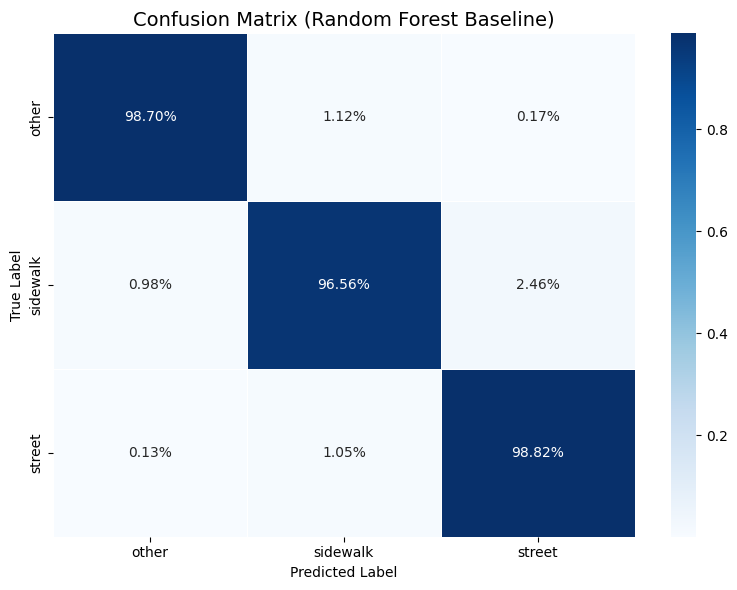

Reading the matrix:
  Each row = what the true label was
  Each column = what the model predicted
  Diagonal = correct (we want these high)
  Off-diagonal = mistakes (we want these low)


In [9]:
# ── Confusion Matrix ─────────────────────────────────────────────────────
# Shows where the model gets confused:
# Rows = true labels, Columns = predicted labels
# Diagonal = correct predictions
# Off-diagonal = mistakes

cm = confusion_matrix(y_test_3, y_pred, labels=[0, 2, 11])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalize by row

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.5
)
plt.title("Confusion Matrix (Random Forest Baseline)", fontsize=14)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

print("Reading the matrix:")
print("  Each row = what the true label was")
print("  Each column = what the model predicted")
print("  Diagonal = correct (we want these high)")
print("  Off-diagonal = mistakes (we want these low)")

Cell 9 — Feature importance

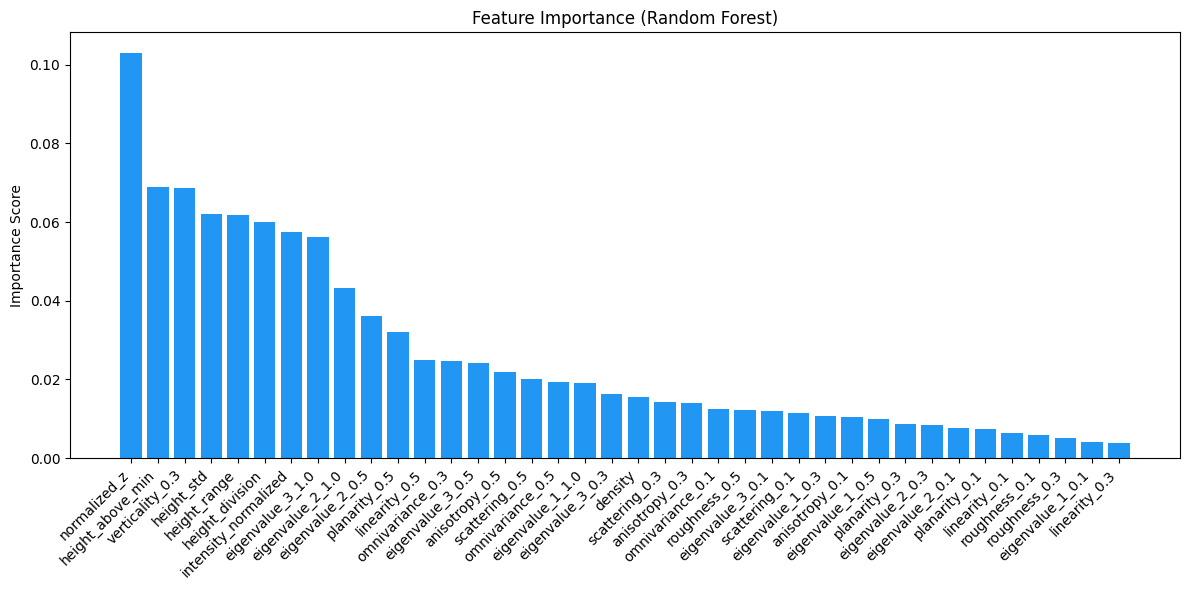

Top 5 most important features:
  1. normalized_z: 0.1031
  2. height_above_min: 0.0689
  3. verticality_0.3: 0.0687
  4. height_std: 0.0622
  5. height_range: 0.0618


In [10]:
# ── Feature Importance ───────────────────────────────────────────────────
# Which features does the model rely on most?
# This tells us what geometric properties best distinguish 
# sidewalk from road from other

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # sort descending

plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_names)), 
        importances[indices], 
        color="#2196F3")
plt.xticks(range(len(feature_names)), 
           [feature_names[i] for i in indices], 
           rotation=45, ha="right")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for i in range(min(5, len(feature_names))):
    print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

Why feature importance matters?
This validates our approach. If planarity and roughness are at the top, it means the model is learning geometry — not memorising map coordinates. James's SHAP analysis showed the same thing.

Cell 10 — Save the model

In [14]:
# ── Save the model ───────────────────────────────────────────────────────
# Save the trained model and scaler so we can:
# 1. Apply it to new cities without retraining
# 2. Pass it to Ahmed for boundary extraction
# 3. Use it as baseline to compare against deep learning later

import os
os.makedirs("models", exist_ok=True)

city = "riga"  # change this for each city
os.makedirs("models", exist_ok=True)
joblib.dump(rf,     f"models/rf_{city}_classifier.joblib")
joblib.dump(scaler, f"models/rf_{city}_scaler.joblib")
print(f"✅ Model saved to models/rf_{city}_classifier.joblib")
print(f"✅ Scaler saved to models/rf_{city}_scaler.joblib")

✅ Model saved to models/rf_riga_classifier.joblib
✅ Scaler saved to models/rf_riga_scaler.joblib
